<a href="https://colab.research.google.com/github/mahim83/Deep-Learning-Assignments-certificates/blob/main/Assignment2_%E2%80%93_Single_Layer_Perceptron_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [34]:
from google.colab import files
uploaded = files.upload()

Saving glass (2).csv to glass (2).csv


In [35]:
import pandas as pd

data = pd.read_csv("glass.csv")

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (214, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [36]:
X = data.drop("Type", axis=1).values
y = data["Type"].values

In [37]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
classes = np.unique(y)

class_to_index = {c:i for i,c in enumerate(classes)}

y_train_idx = np.array([class_to_index[c] for c in y_train])
y_test_idx = np.array([class_to_index[c] for c in y_test])

num_classes = len(classes)

y_train_enc = np.eye(num_classes)[y_train_idx]
y_test_enc = np.eye(num_classes)[y_test_idx]

In [40]:
n_features = X_train.shape[1]
n_classes = num_classes

np.random.seed(42)

W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

In [41]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [42]:
def forward(X, W, b):

    z = np.dot(X, W) + b
    a = sigmoid(z)

    return a

In [43]:
def compute_loss(y, y_pred):

    loss = -np.mean(
        y*np.log(y_pred + 1e-9) + (1-y)*np.log(1-y_pred + 1e-9)
    )

    return loss

In [44]:
learning_rate = 0.01
epochs = 1000

losses = []

for i in range(epochs):

    y_pred = forward(X_train, W, b)

    loss = compute_loss(y_train_enc, y_pred)
    losses.append(loss)

    dz = y_pred - y_train_enc

    dW = np.dot(X_train.T, dz) / X_train.shape[0]
    db = np.sum(dz, axis=0, keepdims=True) / X_train.shape[0]

    W -= learning_rate * dW
    b -= learning_rate * db

    if i % 100 == 0:
        print("Epoch:", i, "Loss:", loss)

Epoch: 0 Loss: 0.6940325031985514
Epoch: 100 Loss: 0.5574813856196945
Epoch: 200 Loss: 0.4796356140461068
Epoch: 300 Loss: 0.43105449744904084
Epoch: 400 Loss: 0.39857528125289055
Epoch: 500 Loss: 0.3756827745518735
Epoch: 600 Loss: 0.3588567623945176
Epoch: 700 Loss: 0.3460604469421045
Epoch: 800 Loss: 0.3360491659309587
Epoch: 900 Loss: 0.3280275297562781


In [45]:
def predict(X):

    y_pred = forward(X, W, b)

    class_index = np.argmax(y_pred, axis=1)

    return classes[class_index]

In [46]:
y_pred = predict(X_test)

accuracy = np.mean(y_pred == y_test)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.5581395348837209


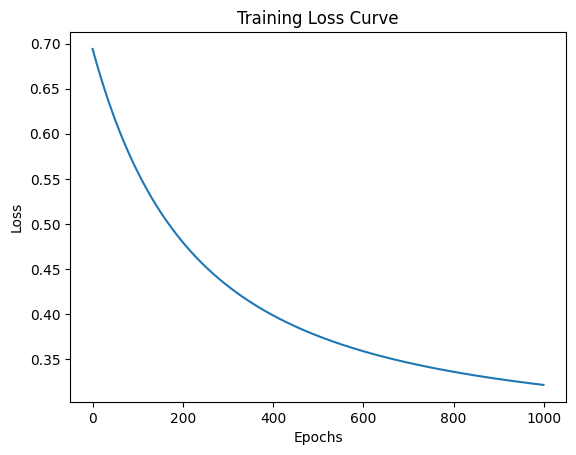

In [47]:
plt.plot(losses)

plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()